In [1]:
%pylab inline

import warnings
warnings.filterwarnings("ignore")
import pickle
from SCCAF import *
from NaiveDE import *
import scanpy as sc
import harmonypy as hm
from sklearn.preprocessing import scale


Populating the interactive namespace from numpy and matplotlib


In [3]:
ad = sc.read('data/FM_hippo_221150_wk.h5')
ad

AnnData object with n_obs × n_vars = 221150 × 19888 
    obs: 'RNA_type', 'age', 'batch', 'batch_orig', 'cell_number', 'date', 'doublet_rate', 'sample', 'scrub_scores', 'scurb_doublets', 'sex', 'suffix', 'percent_mito', 'n_counts', 'n_genes', 'tenX_version', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'cell', 'Hochgerner1', 'Hochgerner2', 'doublet_score_zh', 'louvain', 'louvain_res2', 'label_1', 'label_2', 'class_show', 'Class', 'MonkeyID', 'label_wk', 'cell6', 'label7', 'label8', 'cell8', 'label9', 'label10', 'label_11', 'label_12', 'label_13'
    var: 'gene_ids', 'feature_types', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Hochgerner1_colors', 'Hochgerner2_colors', 'MonkeyID_colors', 'batch_colors', 'cell6_colors', 'cell8_colors', 'cell_colors', 'class_show_colors', 'hvg', 'label10_colors', 'label7_colors', 'label8_colors', 'label9_col

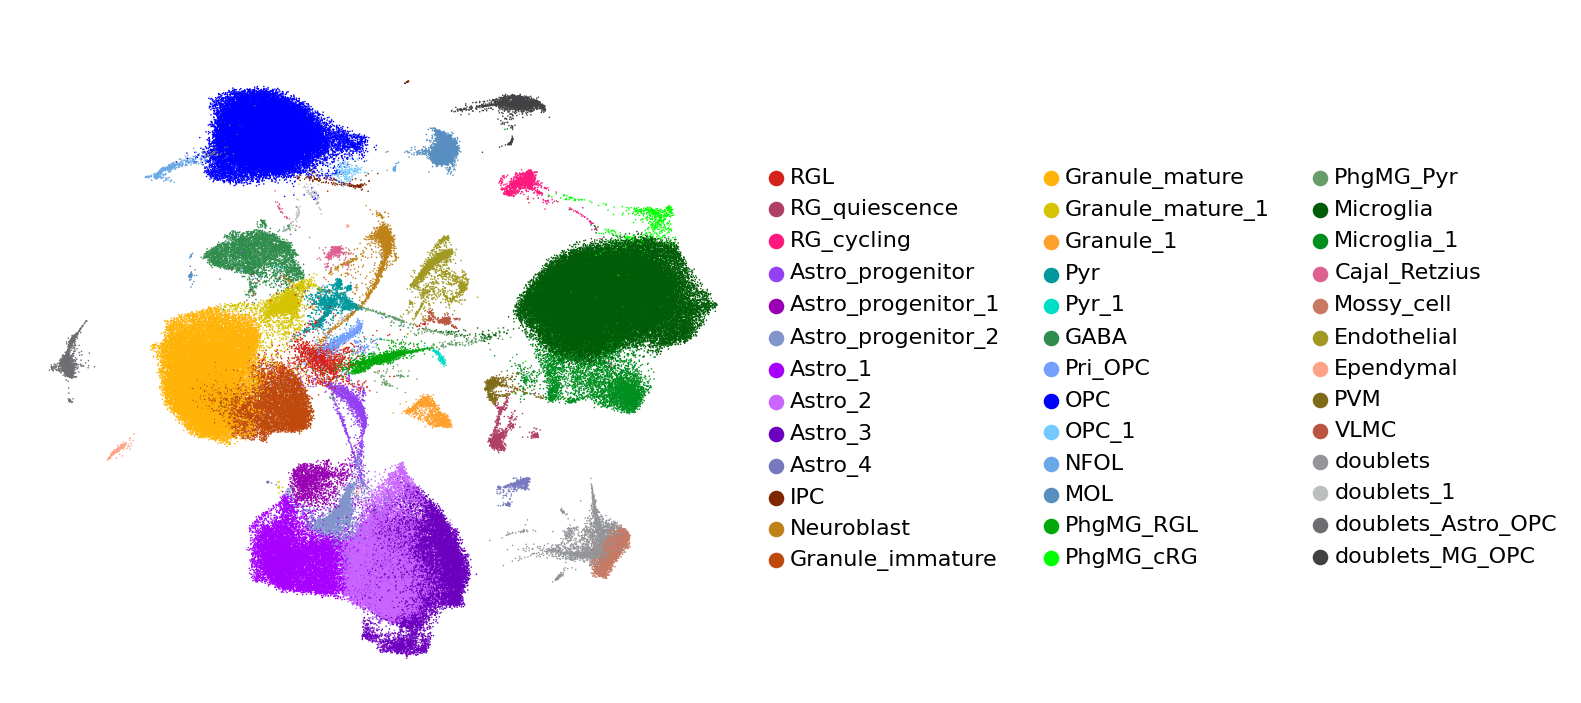

In [14]:
matplotlib.rcParams.update({'font.size': 10})
fig = plt.figure(constrained_layout=True,figsize=(10,4.5))
#sns.despine()

gs = GridSpec(1, 1, figure=fig)
#ax1 = fig.add_subplot(gs[0, 0:])
ax2 = fig.add_subplot(gs[0, 0])
#ax1.annotate('a', (-1,1.05), size=5, xycoords=ax1.get_xaxis_transform(), weight='bold')
#ax2.annotate('b', (-42,1.03), size=15, xycoords=ax2.get_xaxis_transform(), weight='bold')
#ax6.annotate('c', (0,1.01), size=5, xycoords=ax6.get_xaxis_transform(), weight='bold')

#ax1.imshow(fig1a)
#ax1.set_axis_off()

ax2 = sc.pl.umap(ad, color=['label_13'],ax=ax2,\
           legend_fontsize=10,title=' ', show=False, size=2, frameon = False)

ax2.spines['bottom'].set_color('#000000')
ax2.spines['left'].set_color('#000000') 
ax2.spines['top'].set_color('#FFFFFF')
ax2.spines['right'].set_color('#FFFFFF')
ax2.set_facecolor('white')

ax2.xaxis.label.set_size(12)
ax2.yaxis.label.set_size(12)


In [8]:


#Mt1,Dclk1,Nnat,Igfbpl1,Tmsb10,Stmn2,Sulf2,Lhfpl3,Ermn,Epn2,Ermn,Efnb3,Dbndd2, andStmn4

RGL_marker = ['SLC1A3','SOX2','GFAP']
RGL_young_marker = ['DBI','FABP7']
aNSC_marker = ['HMGB2']
NB_marker = ['SOX4','NNAT']
MicroGlia_marker = ['C1QA',]
#Astro1_marker = ['AQP4']
CA3_Pyr_marker = ['RGS4','ELAVL2']
Cajal_Retzius_marker = ['RELN']
Endothelial_marker = ['FLT1']
Ependymal_marker = ['CFAP126']
GABA_marker = ['GAD2']
GC_marker = ['PROX1','NPY1R','ERC2']
Granule_1_marker = ['CPLX2']
GC_immature_marker = ['BHLHE22']
OPC_marker = ['C1QL1']
NFOL_marker = ['ENPP6']
MOL_marker = ['MOG']
PVM_marker = ['LYVE1']
VLMC_marker = ['DCN']
nIPC_perin_marker = ['ASCL1','RFC4','MKI67']
nIPC_marker = ['']


#good_gene_list = (Astro1_marker + CA3_Pyr_marker + Cajal_Retzius_marker+Endothelial_marker+Ependymal_marker+GABA_marker+GC_marker+MOL_marker+NFOL_marker+PVM_marker+VLMC_marker+nIPC_perin_marker+OLIG_marker) #add here
good_gene_list = RGL_marker +  aNSC_marker+ nIPC_perin_marker + NB_marker + GC_marker+Granule_1_marker\
                 + CA3_Pyr_marker + GABA_marker  \
                 + OPC_marker + NFOL_marker   + MOL_marker + MicroGlia_marker + Cajal_Retzius_marker\
                 + Endothelial_marker + Ependymal_marker + PVM_marker + VLMC_marker 

# label7_color= dict(zip(list(unique(ad.obs['label7'])),list((ad.uns['label7_colors']))))
#palette=label7_color

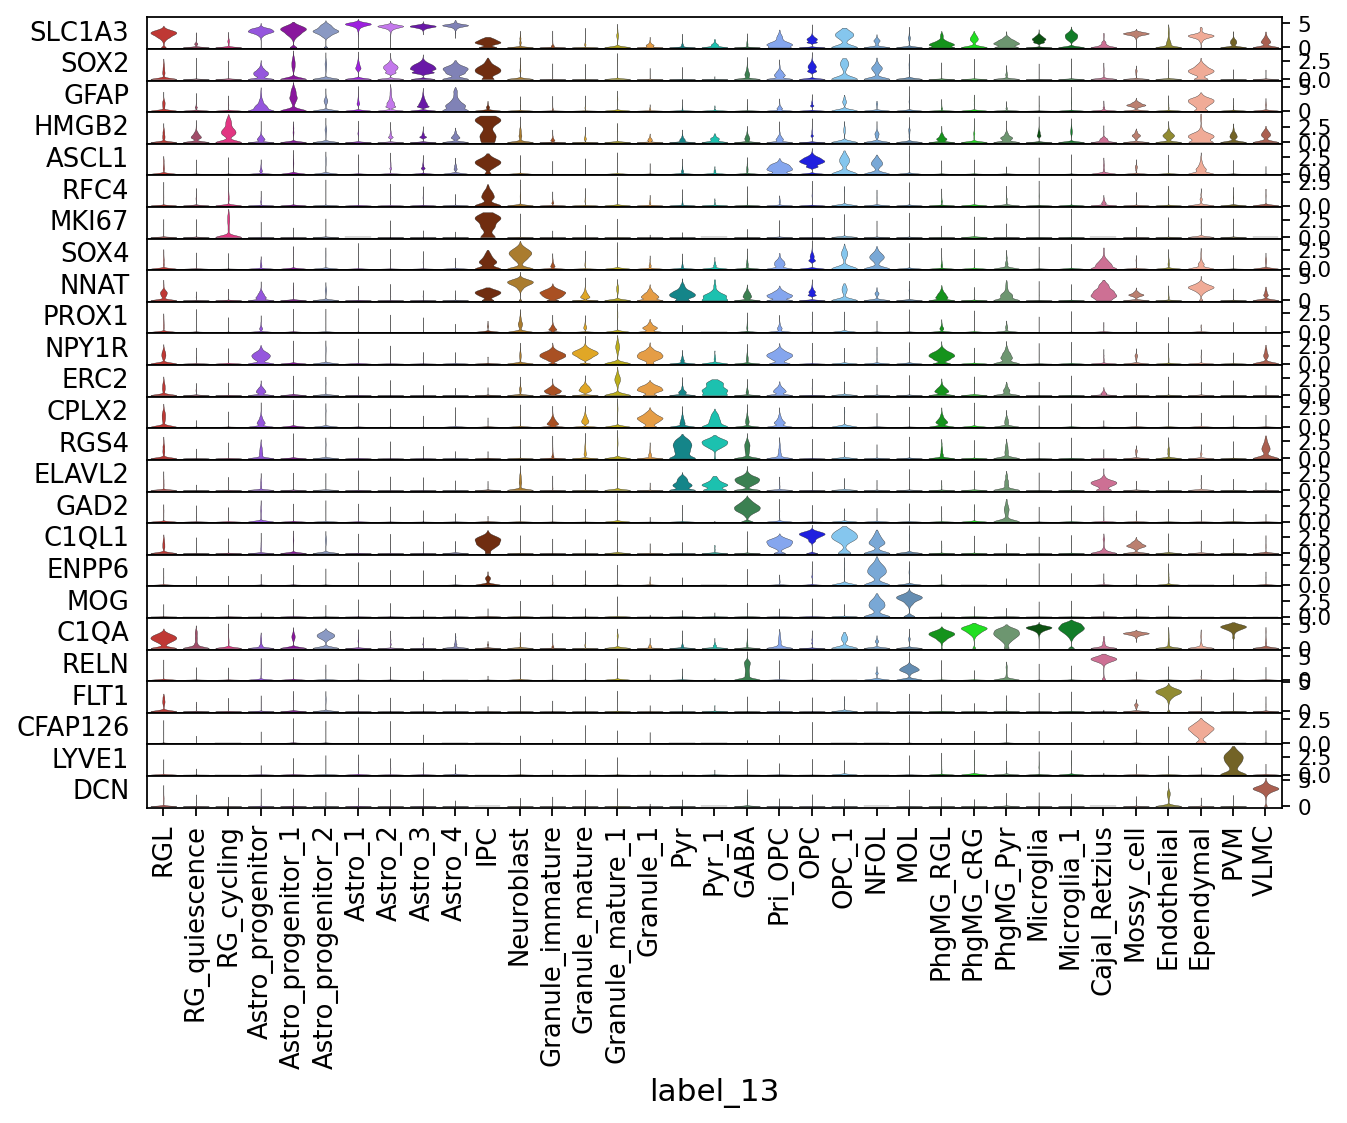

Astro_1
Astro_2
Astro_3
Astro_4
Astro_progenitor
Astro_progenitor_1
Astro_progenitor_2
Cajal_Retzius
Endothelial
Ependymal
GABA
Granule_1
Granule_immature
Granule_mature
Granule_mature_1
IPC
MOL
Microglia
Microglia_1
Mossy_cell
NFOL
Neuroblast
OPC
OPC_1
PVM
PhgMG_Pyr
PhgMG_RGL
PhgMG_cRG
Pri_OPC
Pyr
Pyr_1
RGL
RG_cycling
RG_quiescence
VLMC


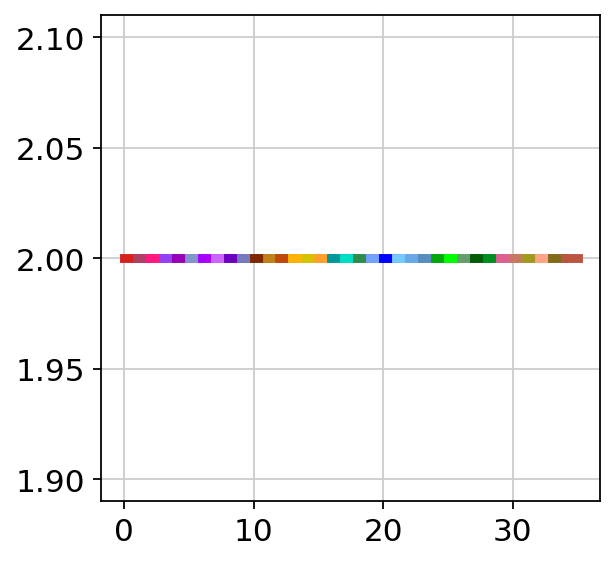

In [13]:
sc.set_figure_params(dpi_save=600,fontsize = 14)

ad_sub = ad[~ad.obs['label_13'].isin(['doublets', 'doublets_1','doublets_Astro_OPC', 'doublets_MG_OPC', ]),:]

ad_color = dict(zip(list(unique(ad_sub.obs['label_13'])),list((ad_sub.uns['label_11_colors']))))
#CGE_color = dict(zip(list(unique(CGE.obs['cell_label'])),list((CGE.uns['cell_label_colors']))))

#cluster_seq = key.uns['dendrogram_cell_label']['dendrogram_info']['ivl']
cluster_seq = list(ad_color.keys())

plot_gene = good_gene_list
sc.pl.stacked_violin(ad_sub, groupby='label_13',\
                     var_names= good_gene_list, jitter=False,layer = 'raw',
                     swap_axes = True,dendrogram = False,figsize=(10,6.5),\
                    linewidth = 0.15, save = "/label_13_Marker_gene_violin_CPM_noDoublets.pdf",palette=ad_sub.uns['label_13_colors'])

plt.figure()




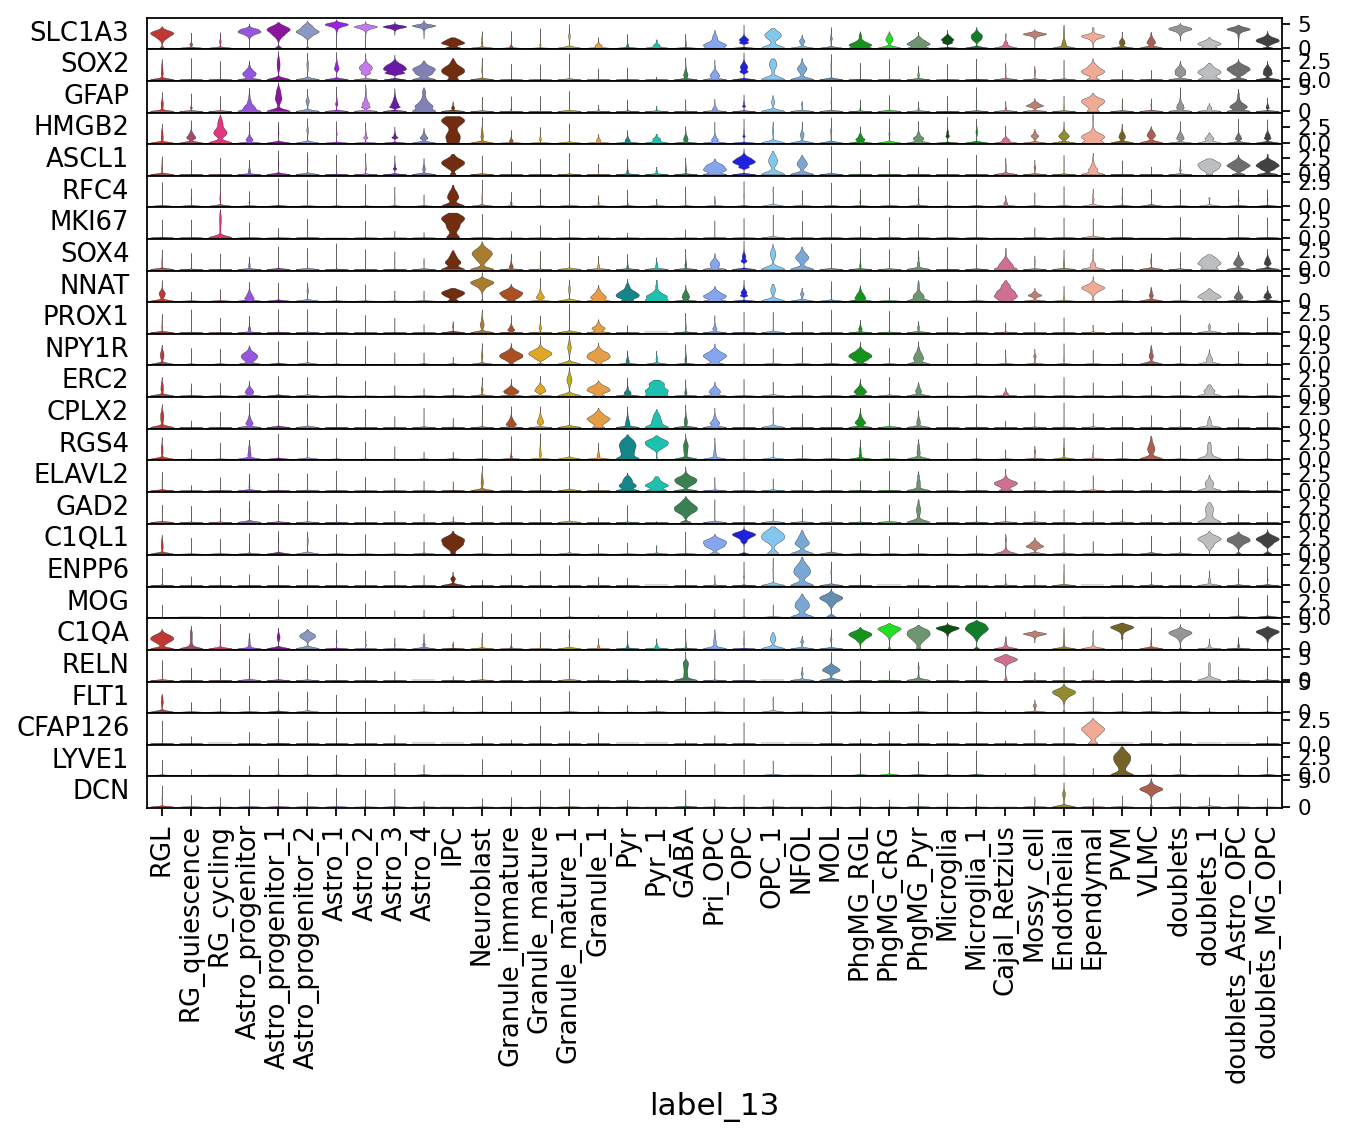

Astro_1
Astro_2
Astro_3
Astro_4
Astro_progenitor
Astro_progenitor_1
Astro_progenitor_2
Cajal_Retzius
Endothelial
Ependymal
GABA
Granule_1
Granule_immature
Granule_mature
Granule_mature_1
IPC
MOL
Microglia
Microglia_1
Mossy_cell
NFOL
Neuroblast
OPC
OPC_1
PVM
PhgMG_Pyr
PhgMG_RGL
PhgMG_cRG
Pri_OPC
Pyr
Pyr_1
RGL
RG_cycling
RG_quiescence
VLMC
doublets
doublets_1
doublets_Astro_OPC
doublets_MG_OPC


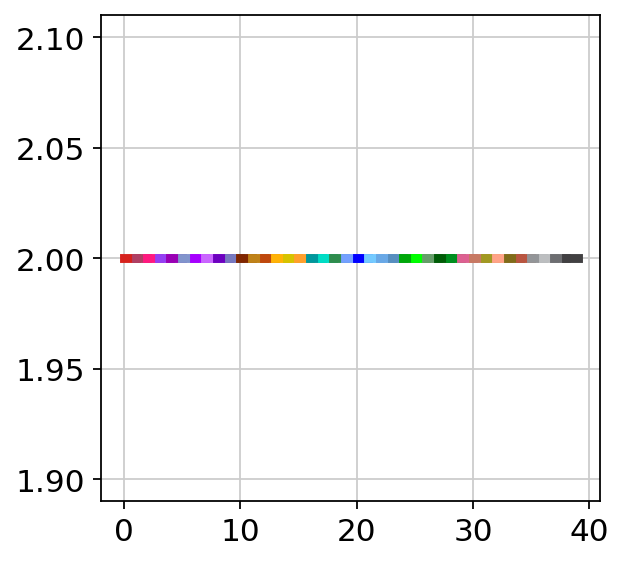

In [12]:
sc.set_figure_params(dpi_save=600,fontsize = 14)

#ad_sub = ad[~ad.obs['label_13'].isin(['doublets', 'doublets_1','doublets_Astro_OPC', 'doublets_MG_OPC', ]),:]

ad_color = dict(zip(list(unique(ad.obs['label_13'])),list((ad.uns['label_11_colors']))))
#CGE_color = dict(zip(list(unique(CGE.obs['cell_label'])),list((CGE.uns['cell_label_colors']))))

#cluster_seq = key.uns['dendrogram_cell_label']['dendrogram_info']['ivl']
cluster_seq = list(ad_color.keys())

plot_gene = good_gene_list
sc.pl.stacked_violin(ad, groupby='label_13',\
                     var_names= good_gene_list, jitter=False,layer = 'raw',
                     swap_axes = True,dendrogram = False,figsize=(10,6.5),\
                    linewidth = 0.15, save = "/label_13_Marker_gene_violin_all.pdf",palette=ad.uns['label_13_colors'])

plt.figure()


# plot genes

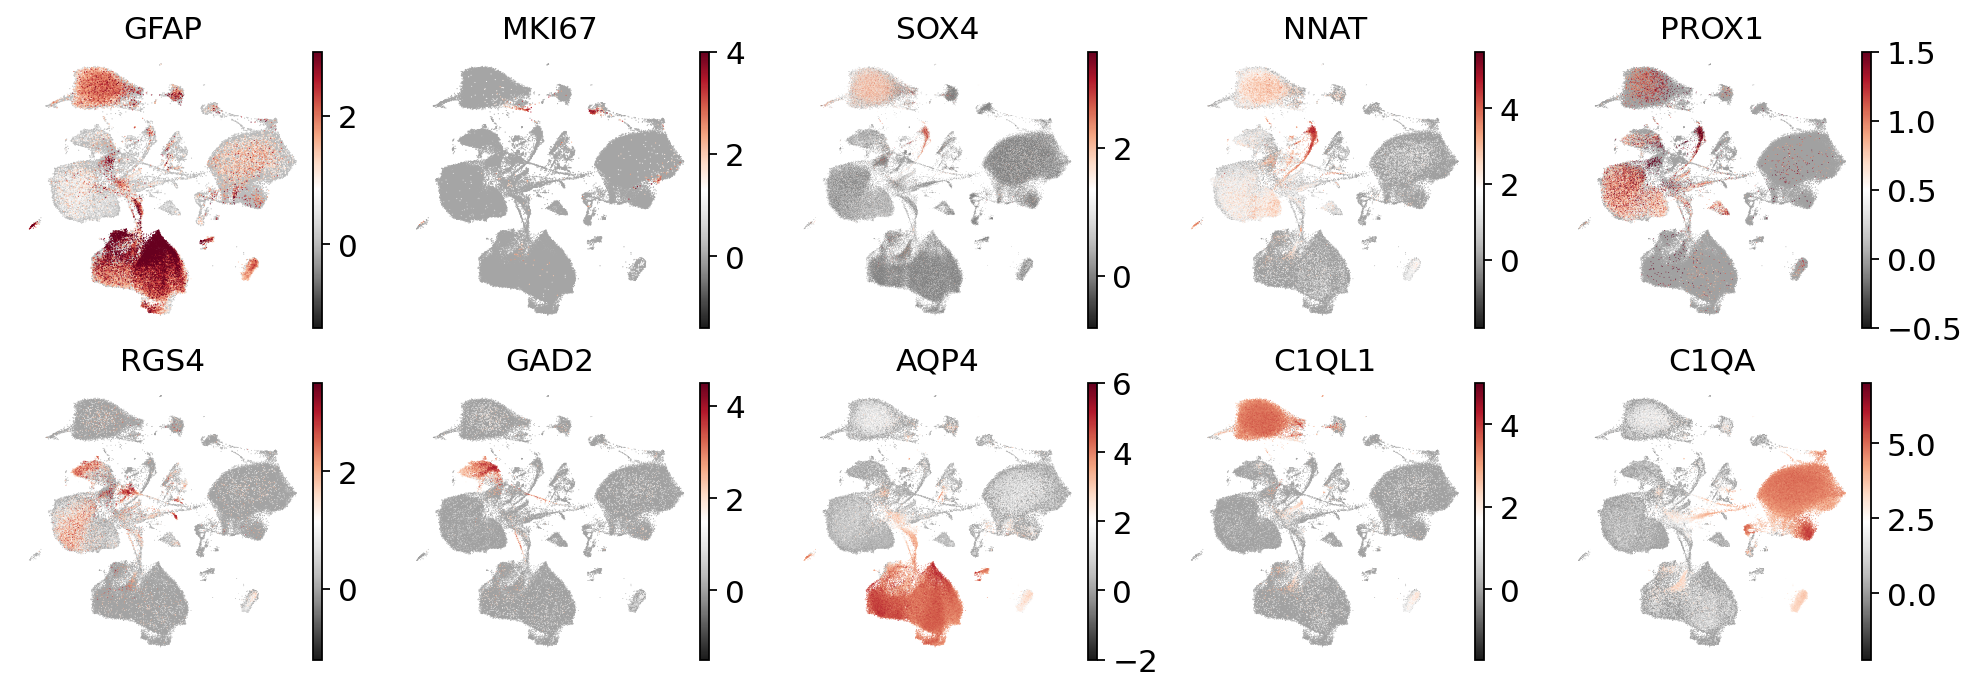

In [57]:
matplotlib.rcParams.update({'font.size': 14})
fig = plt.figure(figsize=(15,5))
#sns.despine()

gs = GridSpec(2,5, figure=fig)
#ax1 = fig.add_subplot(gs[0, 0:])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[0, 3])
ax5 = fig.add_subplot(gs[0, 4])

ax6 = fig.add_subplot(gs[1, 0])
ax7 = fig.add_subplot(gs[1, 1])
ax8 = fig.add_subplot(gs[1, 2])
ax9 = fig.add_subplot(gs[1, 3])
ax10 = fig.add_subplot(gs[1, 4])




#ax1.annotate('a', (-1,1.05), size=5, xycoords=ax1.get_xaxis_transform(), weight='bold')
#ax2.annotate('b', (-42,1.03), size=15, xycoords=ax2.get_xaxis_transform(), weight='bold')
#ax6.annotate('c', (0,1.01), size=5, xycoords=ax6.get_xaxis_transform(), weight='bold')

#ax1.imshow(fig1a)
#ax1.set_axis_off()

gl = ['GFAP','MKI67','SOX4','NNAT','PROX1',\
      'RGS4','GAD2','AQP4','C1QL1','C1QA']

vmn = [-1.3,-1.4,-0.81, -1.8, -0.5,\
       -1.2, -1.5,-2, -1.7, -2.2]
vmx = [3,4,3.5,5.5,1.5,
       3.5,4.5,6,5,7]
#ax1 = sc.pl.umap(ad_sub,  show=False, ax = ax1)
ax1 = sc.pl.umap(ad_sub, color=gl[0],ax=ax1,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[0], vmax = vmx[0],\
           legend_fontsize=10,title=gl[0], show=False,  frameon = False, s = 1)

ax2 = sc.pl.umap(ad_sub, color=gl[1],ax=ax2,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[1],vmax = vmx[1], \
           legend_fontsize=10,title=gl[1], show=False, frameon = False,s = 1)

ax3 = sc.pl.umap(ad_sub, color=gl[2],ax=ax3,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[2],vmax = vmx[2], \
           legend_fontsize=10,title=gl[2], show=False,  frameon = False,s = 0.2)

ax4 = sc.pl.umap(ad_sub, color=gl[3],ax=ax4,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[3], vmax = vmx[3],\
           legend_fontsize=10,title=gl[3], show=False,  frameon = False)

ax5 = sc.pl.umap(ad_sub, color=gl[4],ax=ax5,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[4],vmax = vmx[4], \
           legend_fontsize=10,title=gl[4], show=False,  frameon = False)

ax6 = sc.pl.umap(ad_sub, color=gl[5],ax=ax6,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[5], vmax = vmx[5],\
           legend_fontsize=10,title=gl[5], show=False,  frameon = False)

ax7 = sc.pl.umap(ad_sub, color=gl[6],ax=ax7,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[6], vmax = vmx[6],\
           legend_fontsize=10,title=gl[6], show=False,  frameon = False)

ax8 = sc.pl.umap(ad_sub, color=gl[7],ax=ax8,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[7], vmax = vmx[7],\
           legend_fontsize=10,title=gl[7], show=False, frameon = False)

ax9 = sc.pl.umap(ad_sub, color=gl[8],ax=ax9,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[8], vmax = vmx[8],\
           legend_fontsize=10,title=gl[8], show=False,  frameon = False)

ax10 = sc.pl.umap(ad_sub, color=gl[9],ax=ax10,legend_loc = 'none',cmap = 'RdGy_r',vmin = vmn[9], vmax = vmx[9],\
           legend_fontsize=10,title=gl[9], show=False,  frameon = False)



#ax2.spines['bottom'].set_color('#000000')
#ax2.spines['left'].set_color('#000000') 
#ax2.spines['top'].set_color('#FFFFFF')
#ax2.spines['right'].set_color('#FFFFFF')
#ax2.set_facecolor('white')

#ax2.xaxis.label.set_size(12)
#ax2.yaxis.label.set_size(12)


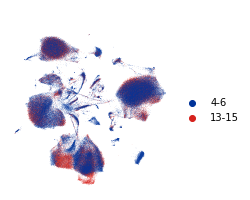

In [19]:
matplotlib.rcParams.update({'font.size': 14})
fig = plt.figure(constrained_layout=True,figsize=(3.7,3))
#sns.despine()

#ad.uns['age_colors'] = ['#279e68','#2E2790','#4D80E4'] #green blue
#ad.uns['age_group_colors'] = ['#FFB307','#D6221D'] #red orange
#ad_sub.uns['age_group_colors'] = ['#D6221D','#003399']
gs = GridSpec(1, 1, figure=fig)
#ax1 = fig.add_subplot(gs[0, 0:])
ax2 = fig.add_subplot(gs[0, 0])
#ax1.annotate('a', (-1,1.05), size=5, xycoords=ax1.get_xaxis_transform(), weight='bold')
#ax2.annotate('b', (-42,1.03), size=15, xycoords=ax2.get_xaxis_transform(), weight='bold')
#ax6.annotate('c', (0,1.01), size=5, xycoords=ax6.get_xaxis_transform(), weight='bold')

#ax1.imshow(fig1a)
#ax1.set_axis_off()

ax2 = sc.pl.umap(ad_sub, color=['age_group'],ax=ax2, s = 0.3, \
           legend_fontsize=10,title=' ', show=False,  frameon = False)

#ax2.spines['bottom'].set_color('#000000')
#ax2.spines['left'].set_color('#000000') 
#ax2.spines['top'].set_color('#FFFFFF')
#ax2.spines['right'].set_color('#FFFFFF')
ax2.set_facecolor('white')

ax2.xaxis.label.set_size(12)
ax2.yaxis.label.set_size(12)


fig.tight_layout(w_pad=0.3)
#plt.show()
plt.savefig("Figure/V6_cell/Fig1_summary/Fig1_umap_age_group_noDB.pdf", dpi = 200)
plt.savefig("Figure/V6_cell/Fig1_summary/Fig1_umap_age_group_noDB.png", dpi= 600)